In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import geopandas as gpd
import pandas as pd
import ocha_stratus as stratus
from dotenv import load_dotenv
import matplotlib.pyplot as plt

from src.datasources import grrr

load_dotenv()

True

## Load data

In [3]:
gdf_lga_sel = stratus.load_geoparquet_from_blob(
    "ds-aa-nga-flooding/processed/selected_lgas.parquet"
)

In [4]:
gdf_gauges = grrr.get_gauges_by_area(
    gdf_lga_sel,
    include_non_quality_verified=True
)
print(f"Total gauges in search area: {len(gdf_gauges)}")
print(f"  Quality-verified: {gdf_gauges.quality_verified.sum()}")

Total gauges in search area: 847
  Quality-verified: 31


In [5]:
gdf_codab = stratus.codab.load_codab_from_blob("NGA", admin_level=0)
gdf_lga = stratus.codab.load_codab_from_blob("NGA", admin_level=2)

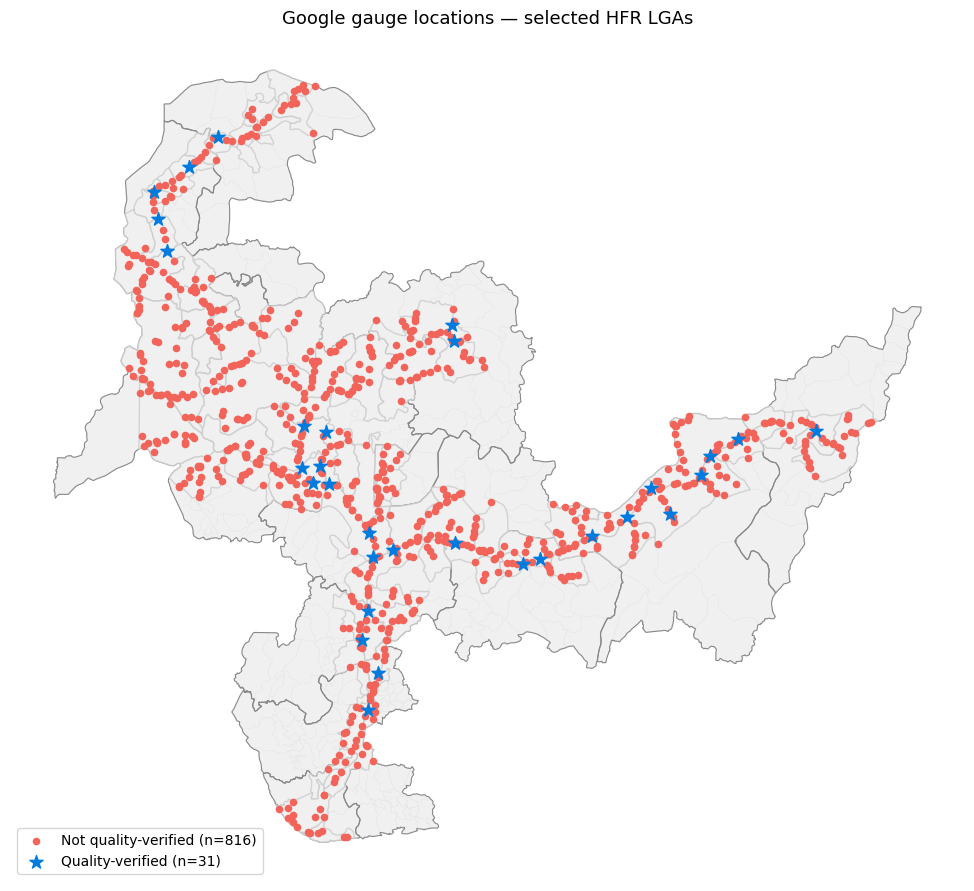

In [6]:
states = gdf_lga_sel["ADM1_EN"].unique().tolist()
gdf_lga_states = gdf_lga[gdf_lga["ADM1_EN"].isin(states)]
gdf_adm1_states = gdf_lga_states.dissolve(by="ADM1_EN").reset_index()

qv = gdf_gauges[gdf_gauges["quality_verified"]]
non_qv = gdf_gauges[~gdf_gauges["quality_verified"]]

fig, ax = plt.subplots(figsize=(10, 9))

gdf_lga_states.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.1)
gdf_adm1_states.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)
gdf_lga_sel.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=1, alpha=0.8, zorder=3)

non_qv.plot(ax=ax, color="#F2645A", markersize=20, zorder=5, label=f"Not quality-verified (n={len(non_qv)})")
qv.plot(ax=ax, color="#007CE0", markersize=100, marker="*", zorder=6, label=f"Quality-verified (n={len(qv)})")

ax.legend(fontsize=10, loc="lower left")
ax.set_title("Google gauge locations — selected HFR LGAs", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/google_gauge_locations_hfr.png", dpi=300, bbox_inches="tight")

## Check model performance

How well does the reanalysis data from each Google gauge predict peaks in flooding from Floodscan?

In [7]:
df_floodscan = stratus.load_parquet_from_blob("ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas.parquet")

In [8]:
gauges_with_model = gdf_gauges[gdf_gauges["has_model"] == True]
print(f"Loading reanalysis for {len(gauges_with_model)} gauges with models...")

gauge_ids = gauges_with_model["gauge_id"].tolist()
ds_ra = grrr.load_reanalysis(gauge=gauge_ids)
df_ra = grrr.process_reanalysis(ds_ra)
df_ra["date"] = pd.to_datetime(df_ra["valid_time"]).dt.normalize()

print(f"Reanalysis loaded: {df_ra['date'].min().date()} to {df_ra['date'].max().date()}")

gdf_gauge_lga = gpd.sjoin_nearest(
    gauges_with_model[["gauge_id", "quality_verified", "geometry"]],
    gdf_lga_sel[["ADM2_PCODE", "ADM2_EN", "geometry"]],
    how="left",
).drop(columns=["index_right"])

print(gdf_gauge_lga[["gauge_id", "ADM2_EN", "quality_verified"]].to_string())

Loading reanalysis for 847 gauges with models...


I0506 09:44:47.151694 1780959 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0506 09:44:47.159440 1780996 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(115, generation: 1)


Reanalysis loaded: 1980-01-01 to 2023-12-23
              gauge_id            ADM2_EN  quality_verified
24    hybas_1120022310              Brass             False
25    hybas_1120022330              Brass             False
28    hybas_1120022400              Brass             False
29    hybas_1120022420              Brass             False
30    hybas_1120022440              Brass             False
31    hybas_1120022460      Southern Ijaw             False
32    hybas_1120022480      Southern Ijaw             False
33    hybas_1120022500      Southern Ijaw             False
34    hybas_1120022520      Southern Ijaw             False
35    hybas_1120022540      Southern Ijaw             False
56    hybas_1120671610               Gada             False
60    hybas_1120674520               Gada             False
69    hybas_1120677950               Gada             False
73    hybas_1120679930            Goronyo             False
75    hybas_1120680300               Gada             Fa

/Users/hannahker/Desktop/AA/ds-aa-nga-flooding/.venv/lib/python3.12/site-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [ ]:
from scipy import stats as scipy_stats

df_fs_daily = df_floodscan.copy()
df_fs_daily["date"] = pd.to_datetime(df_fs_daily["valid_date"]).dt.normalize()

MAX_LAG = 14
MIN_LAG = -7
MIN_OBS = 60

def remove_seasonal(df, col, date_col="date"):
    """Subtract long-run day-of-year mean to get anomalies."""
    df = df.copy()
    df["doy"] = df[date_col].dt.dayofyear
    doy_mean = df.groupby("doy")[col].transform("mean")
    df[f"{col}_anom"] = df[col] - doy_mean
    return df

results = []

for _, gauge_row in gdf_gauge_lga.iterrows():
    gauge_id = gauge_row["gauge_id"]
    pcode = gauge_row["ADM2_PCODE"]
    lga_name = gauge_row["ADM2_EN"]
    qv = gauge_row["quality_verified"]

    df_sf = df_ra[df_ra["gauge_id"] == gauge_id][["date", "streamflow"]].copy()
    df_sfed = df_fs_daily[df_fs_daily["pcode"] == pcode][["date", "mean"]].copy()

    df_sf = remove_seasonal(df_sf, "streamflow")
    df_sfed = remove_seasonal(df_sfed, "mean")

    df_merged = df_sf.merge(df_sfed, on="date").dropna(subset=["streamflow_anom", "mean_anom"])
    df_merged = df_merged[df_merged["date"].dt.month.between(6, 11)]
    if len(df_merged) < MIN_OBS:
        continue

    best_r, best_lag, best_p = 0.0, 0, 1.0
    lag_rs = {}
    for lag in range(MIN_LAG, MAX_LAG + 1):
        sfed_shifted = df_merged["mean_anom"].shift(-lag)
        sfed_raw_shifted = df_merged["mean"].shift(-lag)
        valid = (
            df_merged["streamflow_anom"].notna()
            & sfed_shifted.notna()
            & (sfed_raw_shifted > 0)
        )
        if valid.sum() < MIN_OBS:
            continue
        r, p = scipy_stats.spearmanr(df_merged["streamflow_anom"][valid], sfed_shifted[valid])
        lag_rs[lag] = r
        if abs(r) > abs(best_r):
            best_r, best_lag, best_p = r, lag, p

    results.append({
        "gauge_id": gauge_id,
        "pcode": pcode,
        "lga_name": lga_name,
        "quality_verified": qv,
        "best_r": best_r,
        "best_lag_days": best_lag,
        "best_p": best_p,
        "lag_profile": lag_rs,
        "n_obs": len(df_merged),
    })

df_results = pd.DataFrame(results).sort_values("best_r", ascending=False).reset_index(drop=True)
print(f"Correlations computed for {len(df_results)} gauges")
df_results[["gauge_id", "lga_name", "quality_verified", "best_r", "best_lag_days", "best_p", "n_obs"]]

In [ ]:
import matplotlib.colors as mcolors

gdf_gauge_results = gauges_with_model.merge(
    df_results[["gauge_id", "best_r", "best_lag_days"]],
    on="gauge_id",
    how="inner",
)

norm = mcolors.Normalize(vmin=-1, vmax=1)
cmap = plt.cm.RdBu_r

# --- Map 1: gauges coloured by best correlation ---
fig, ax = plt.subplots(figsize=(10, 9))

gdf_lga_states.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)
gdf_adm1_states.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)
gdf_lga_sel.plot(ax=ax, facecolor="none", edgecolor="#007CE0", linewidth=1.2, zorder=3)

sc = ax.scatter(
    gdf_gauge_results.geometry.x,
    gdf_gauge_results.geometry.y,
    c=gdf_gauge_results["best_r"],
    cmap=cmap,
    norm=norm,
    s=50,
    zorder=5,
    edgecolors="white",
    linewidths=0.4,
)

qv_res = gdf_gauge_results[gdf_gauge_results["quality_verified"]]
ax.scatter(
    qv_res.geometry.x, qv_res.geometry.y,
    c=qv_res["best_r"], cmap=cmap, norm=norm,
    s=200, marker="*", zorder=6, edgecolors="black", linewidths=0.6,
)

plt.colorbar(sc, ax=ax, orientation="horizontal", shrink=0.5, pad=0.02, label="Best Spearman ρ (Jun–Nov)")
ax.set_title("Google gauge best correlation with Floodscan SFED (Jun–Nov, Spearman ρ)\n(blue outline = selected LGAs, ★ = quality-verified)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/gauge_best_r_map_hfr.png", dpi=200, bbox_inches="tight")

# --- Map 2: LGA choropleth — best gauge r per LGA ---
df_lga_best_r = (
    gdf_gauge_lga[["gauge_id", "ADM2_PCODE"]]
    .merge(df_results[["gauge_id", "best_r"]], on="gauge_id")
    .sort_values("best_r", ascending=False)
    .drop_duplicates("ADM2_PCODE")
    .rename(columns={"best_r": "best_gauge_r"})
)

gdf_lga_choropleth = gdf_lga_sel.merge(df_lga_best_r[["ADM2_PCODE", "best_gauge_r"]], on="ADM2_PCODE", how="left")

fig, ax = plt.subplots(figsize=(10, 9))

gdf_lga_states.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)
gdf_adm1_states.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)

gdf_lga_choropleth.plot(
    ax=ax,
    column="best_gauge_r",
    cmap=cmap,
    norm=norm,
    edgecolor="#888888",
    linewidth=0.5,
    legend=True,
    legend_kwds={"label": "Best gauge Spearman ρ (Jun–Nov)", "orientation": "horizontal", "shrink": 0.5, "pad": 0.02},
    missing_kwds={"color": "#cccccc", "edgecolor": "#888888", "label": "No gauges"},
    zorder=3,
)

for _, row in gdf_lga_choropleth.iterrows():
    if pd.notna(row["best_gauge_r"]):
        centroid = row.geometry.centroid
        r = row["best_gauge_r"]
        color = "#E63946" if r < 0 else ("white" if r > 0.5 else "black")
        ax.text(
            centroid.x, centroid.y, f"{r:.2f}",
            ha="center", va="center", fontsize=7, fontweight="bold", color=color,
        )

ax.set_title("Best gauge-SFED Spearman ρ per LGA (Jun–Nov, highest ρ gauge selected)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/lga_best_r_choropleth_hfr.png", dpi=200, bbox_inches="tight")

In [18]:
stratus.upload_parquet_to_blob(
    df_lga_best_r[["ADM2_PCODE", "best_gauge_r"]],
    "ds-aa-nga-flooding/processed/web_map/google_best_r.parquet",
)

## Return period comparison: Floodscan vs Google streamflow

Per LGA, compare annual return periods derived from Floodscan SFED peaks against return periods from the best-correlated Google gauge's streamflow peaks. A high RP correlation (dark blue) means the gauge reliably identifies which years had the most severe flooding, making it a stronger candidate for an anticipatory action trigger. A low or negative correlation (red) indicates the gauge's severity ranking disagrees with observed flooding and should not be used for triggering.

In [13]:
from src.utils import rp_calc

# --- Floodscan annual max + RP per LGA ---
df_fs = df_floodscan.copy()
df_fs["year"] = pd.to_datetime(df_fs["valid_date"]).dt.year
df_fs = df_fs[df_fs["year"] != 2026]

df_fs_valid = df_fs.groupby(["pcode", "year"]).filter(lambda x: x["mean"].notna().any())
df_fs_max = df_fs_valid.loc[
    df_fs_valid.groupby(["pcode", "year"])["mean"].idxmax()
][["pcode", "year", "mean"]]

df_fs_rp = rp_calc.calculate_groups_rp(df_fs_max, by=["pcode"], col_name="mean", ascending=False)
df_fs_rp = df_fs_rp.rename(columns={"mean_rp": "fs_rp", "mean": "fs_mean"})

# --- Streamflow annual max + RP per gauge ---
df_sf = df_ra.copy()
df_sf["year"] = pd.to_datetime(df_sf["valid_time"]).dt.year
df_sf = df_sf[df_sf["year"] != 2026]

df_sf_max = (
    df_sf.groupby(["gauge_id", "year"])["streamflow"]
    .max()
    .reset_index()
)
df_sf_rp = rp_calc.calculate_groups_rp(df_sf_max, by=["gauge_id"], col_name="streamflow", ascending=False)
df_sf_rp = df_sf_rp.rename(columns={"streamflow_rp": "sf_rp"})

# --- For each LGA, pick the best-correlated gauge ---
df_best_gauge = (
    df_results.sort_values("best_r", ascending=False)
    .drop_duplicates("pcode")[["pcode", "gauge_id", "lga_name", "best_r"]]
)

df_sf_rp_lga = df_best_gauge.merge(df_sf_rp, on="gauge_id", how="inner")

df_rp_compare = df_fs_rp.merge(
    df_sf_rp_lga[["pcode", "lga_name", "gauge_id", "best_r", "year", "sf_rp"]],
    on=["pcode", "year"],
    how="inner",
).dropna(subset=["fs_rp", "sf_rp"])

print(f"LGAs with matched RP data: {df_rp_compare['pcode'].nunique()}")
print(f"Year range: {df_rp_compare['year'].min()}\u2013{df_rp_compare['year'].max()}")
df_rp_compare.head()

LGAs with matched RP data: 90
Year range: 1998–2023


,pcode,year,fs_mean,mean_rank,fs_rp,lga_name,gauge_id,best_r,sf_rp
0,NG002001,1998,0.065027,10,2.900000,Demsa,hybas_1120837770,0.615265,7.5000
1,NG002001,1999,0.079550,7,4.142857,Demsa,hybas_1120837770,0.615265,11.2500
2,NG002001,2000,0.044496,18,1.611111,Demsa,hybas_1120837770,0.615265,1.8000
3,NG002001,2001,0.029920,25,1.160000,Demsa,hybas_1120837770,0.615265,2.8125
4,NG002001,2002,0.048605,17,1.705882,Demsa,hybas_1120837770,0.615265,1.8750


In [14]:
import numpy as np

PCODE = "NG008008"  # change to explore — see available pcodes below

available = df_rp_compare[["pcode", "lga_name"]].drop_duplicates()
print("Available pcodes:\n", available.to_string(index=False))

sub = df_rp_compare[df_rp_compare["pcode"] == PCODE]

if sub.empty:
    print(f"\n'{PCODE}' not found in df_rp_compare. Choose a pcode from the list above.")
else:
    lga_name = sub["lga_name"].iloc[0]
    gauge_id = sub["gauge_id"].iloc[0]

    fig, ax = plt.subplots(figsize=(6, 5))

    ax.scatter(sub["sf_rp"], sub["fs_rp"], color="#007CE0", s=50, zorder=3)

    for _, row in sub.iterrows():
        ax.annotate(str(int(row["year"])), (row["sf_rp"], row["fs_rp"]),
                    textcoords="offset points", xytext=(5, 3), fontsize=8, color="#444444")

    if len(sub) >= 3:
        m, b, r, p, _ = scipy_stats.linregress(sub["sf_rp"], sub["fs_rp"])
        x_line = np.linspace(sub["sf_rp"].min(), sub["sf_rp"].max(), 100)
        ax.plot(x_line, m * x_line + b, color="#F2645A", linewidth=1.5, linestyle="--")
        p_str = f"p={p:.2f}" if p >= 0.01 else "p<0.01"
        ax.text(0.97, 0.05, f"r={r:.2f}, {p_str}", transform=ax.transAxes,
                ha="right", va="bottom", fontsize=10,
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="#cccccc", alpha=0.8))

    ax.set_title(f"{lga_name} \u2014 {gauge_id}", fontsize=11)
    ax.set_xlabel("Streamflow RP (years)", fontsize=10)
    ax.set_ylabel("Floodscan RP (years)", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()

Available pcodes:
    pcode          lga_name
NG002001             Demsa
NG002002            Fufore
NG002005             Girei
NG002009           Lamurde
NG002016             Numan
NG002021        Yola South
NG004002      Anambra East
NG004003      Anambra West
NG004016            Ogbaru
NG006001             Brass
NG006003  Kolokuma/Opokuma
NG006006           Sagbama
NG006007     Southern Ijaw
NG006008           Yenegoa
NG007002             Agatu
NG007006              Guma
NG007008         Gwer West
NG007012              Logo
NG007013           Makurdi
NG010011       Ndokwa East
NG010014    Oshimili North
NG010015    Oshimili South
NG012005   Esan South East
NG012007    Etsako Central
NG012008       Etsako East
NG015001             Abaji
NG015004        Gwagwalada
NG015006             Kwali
NG019002            Chikun
NG019004             Igabi
NG019014             Kauru
NG022003           Argungu
NG022004             Augie
NG022005            Bagudo
NG022006      Birnin Kebbi
NG022007 

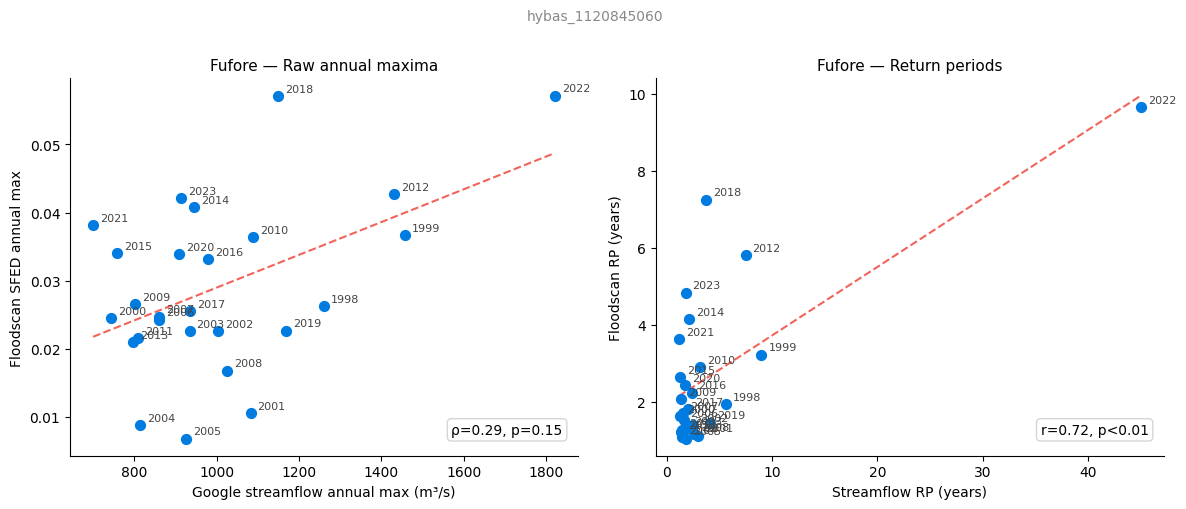

In [30]:
LGA_NAME = "Fufore"  # change to any LGA name from df_rp_compare

match = df_best_gauge[df_best_gauge["lga_name"].str.lower() == LGA_NAME.lower()]

if match.empty:
    available_names = df_best_gauge["lga_name"].sort_values().tolist()
    print(f"'{LGA_NAME}' not found. Available LGAs:\n{available_names}")
else:
    pcode = match["pcode"].iloc[0]
    gauge_id = match["gauge_id"].iloc[0]

    sf = df_sf_max[df_sf_max["gauge_id"] == gauge_id][["year", "streamflow"]]
    fs = df_fs_max[df_fs_max["pcode"] == pcode][["year", "mean"]]
    sub_raw = sf.merge(fs, on="year").dropna()

    sub_rp = df_rp_compare[df_rp_compare["pcode"] == pcode]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, (x_col, y_col, xlabel, ylabel, title_suffix, use_spearman) in zip(axes, [
        ("streamflow", "mean",  "Google streamflow annual max (m³/s)", "Floodscan SFED annual max", "Raw annual maxima", True),
        ("sf_rp",     "fs_rp", "Streamflow RP (years)",               "Floodscan RP (years)",      "Return periods",    False),
    ]):
        sub = sub_raw if x_col == "streamflow" else sub_rp
        ax.scatter(sub[x_col], sub[y_col], color="#007CE0", s=50, zorder=3)
        for _, row in sub.iterrows():
            ax.annotate(str(int(row["year"])), (row[x_col], row[y_col]),
                        textcoords="offset points", xytext=(5, 3), fontsize=8, color="#444444")
        if len(sub) >= 3:
            m, b, r_pearson, p_pearson, _ = scipy_stats.linregress(sub[x_col], sub[y_col])
            x_line = np.linspace(sub[x_col].min(), sub[x_col].max(), 100)
            ax.plot(x_line, m * x_line + b, color="#F2645A", linewidth=1.5, linestyle="--")
            if use_spearman:
                r, p = scipy_stats.spearmanr(sub[x_col], sub[y_col])
                r_label = "ρ"
            else:
                r, p = r_pearson, p_pearson
                r_label = "r"
            p_str = f"p={p:.2f}" if p >= 0.01 else "p<0.01"
            ax.text(0.97, 0.05, f"{r_label}={r:.2f}, {p_str}", transform=ax.transAxes,
                    ha="right", va="bottom", fontsize=10,
                    bbox=dict(boxstyle="round", facecolor="white", edgecolor="#cccccc", alpha=0.8))
        ax.set_title(f"{LGA_NAME} — {title_suffix}", fontsize=11)
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle(gauge_id, fontsize=10, color="#888888", y=1.01)
    plt.tight_layout()

In [15]:
MIN_YEARS = 5

gauge_rp_results = []

for _, gauge_row in gdf_gauge_lga.iterrows():
    gauge_id = gauge_row["gauge_id"]
    pcode = gauge_row["ADM2_PCODE"]
    lga_name = gauge_row["ADM2_EN"]
    qv = gauge_row["quality_verified"]

    sf = df_sf_rp[df_sf_rp["gauge_id"] == gauge_id][["year", "sf_rp"]]
    fs = df_fs_rp[df_fs_rp["pcode"] == pcode][["year", "fs_rp"]]

    merged = sf.merge(fs, on="year").dropna()
    if len(merged) < MIN_YEARS:
        continue

    r, p = scipy_stats.pearsonr(merged["sf_rp"], merged["fs_rp"])
    gauge_rp_results.append({
        "gauge_id": gauge_id,
        "pcode": pcode,
        "lga_name": lga_name,
        "quality_verified": qv,
        "rp_r": r,
        "rp_p": p,
        "n_years": len(merged),
    })

df_gauge_rp = pd.DataFrame(gauge_rp_results).sort_values("rp_r", ascending=False).reset_index(drop=True)
print(f"Gauges with RP correlation: {len(df_gauge_rp)}")
df_gauge_rp.head(10)

Gauges with RP correlation: 846


,gauge_id,pcode,lga_name,quality_verified,rp_r,rp_p,n_years
0,hybas_1120907150,NG023004,Bassa,False,0.950172,1.197418e-13,26
1,hybas_1120899030,NG035014,Wukari,False,0.941551,7.770478e-13,26
2,hybas_1120897100,NG035014,Wukari,True,0.938621,1.376430e-12,26
3,hybas_1121992360,NG023019,Omala,False,0.933858,3.291807e-12,26
4,hybas_1120904990,NG007002,Agatu,False,0.914755,6.254427e-11,26
5,hybas_1120910640,NG007013,Makurdi,False,0.911894,9.154826e-11,26
6,hybas_1120911330,NG007013,Makurdi,False,0.911889,9.161205e-11,26
7,hybas_1120911010,NG007013,Makurdi,False,0.911753,9.325270e-11,26
8,hybas_1121997090,NG007013,Makurdi,False,0.909371,1.267706e-10,26
9,hybas_1120904190,NG023004,Bassa,True,0.900608,3.663276e-10,26


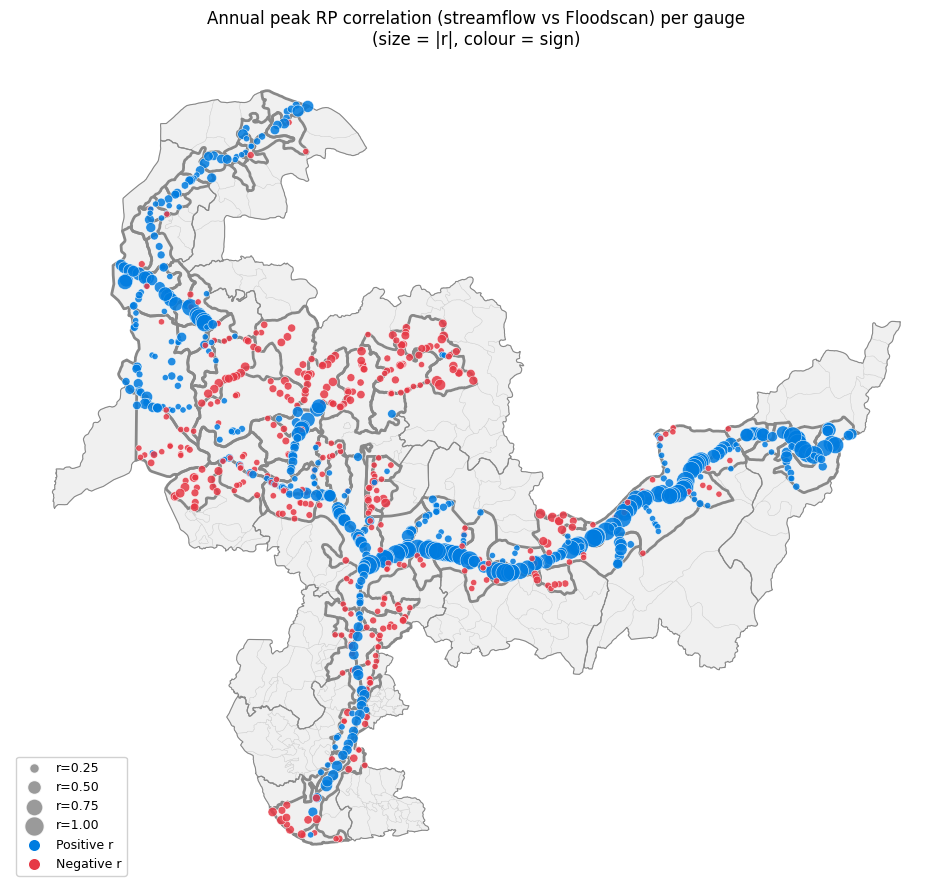

In [17]:
gdf_gauge_rp = gauges_with_model.merge(df_gauge_rp[["gauge_id", "rp_r"]], on="gauge_id", how="inner")

fig, ax = plt.subplots(figsize=(10, 9))

gdf_lga_states.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)
gdf_adm1_states.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)
gdf_lga_sel.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=2.0, zorder=3)

colors = ["#E63946" if r < 0 else "#007CE0" for r in gdf_gauge_rp["rp_r"]]
sizes = (gdf_gauge_rp["rp_r"].abs() * 200).clip(lower=20)

ax.scatter(
    gdf_gauge_rp.geometry.x,
    gdf_gauge_rp.geometry.y,
    c=colors,
    s=sizes,
    zorder=5,
    edgecolors="white",
    linewidths=0.4,
    alpha=0.85,
)

for r_val, label in [(0.25, "r=0.25"), (0.5, "r=0.50"), (0.75, "r=0.75"), (1.0, "r=1.00")]:
    ax.scatter([], [], c="#888888", s=r_val * 200, label=label, alpha=0.85, edgecolors="white")
ax.scatter([], [], c="#007CE0", s=80, label="Positive r", edgecolors="white")
ax.scatter([], [], c="#E63946", s=80, label="Negative r", edgecolors="white")

ax.legend(fontsize=9, loc="lower left", framealpha=0.9)
ax.set_title("Annual peak RP correlation (streamflow vs Floodscan) per gauge\n(size = |r|, colour = sign)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/gauge_rp_correlation_map_hfr.png", dpi=200, bbox_inches="tight")

In [ ]:
df_lga_best_rp_r = (
    df_gauge_rp.sort_values("rp_r", ascending=False)
    .drop_duplicates("pcode")[["pcode", "lga_name", "rp_r"]]
    .rename(columns={"rp_r": "best_rp_r"})
)

gdf_lga_rp_choropleth = gdf_lga_sel.merge(
    df_lga_best_rp_r[["pcode", "best_rp_r"]],
    left_on="ADM2_PCODE",
    right_on="pcode",
    how="left",
)

fig, ax = plt.subplots(figsize=(10, 9))

gdf_lga_states.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)
gdf_adm1_states.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)

gdf_lga_rp_choropleth.plot(
    ax=ax,
    column="best_rp_r",
    cmap=cmap,
    norm=norm,
    edgecolor="#888888",
    linewidth=0.5,
    legend=True,
    legend_kwds={"label": "Best gauge RP Pearson r", "orientation": "horizontal", "shrink": 0.5, "pad": 0.02},
    missing_kwds={"color": "#cccccc", "edgecolor": "#888888", "label": "No gauges"},
    zorder=3,
)

for _, row in gdf_lga_rp_choropleth.iterrows():
    if pd.notna(row["best_rp_r"]):
        centroid = row.geometry.centroid
        r = row["best_rp_r"]
        color = "#E63946" if r < 0 else ("white" if r > 0.5 else "black")
        ax.text(
            centroid.x, centroid.y, f"{r:.2f}",
            ha="center", va="center", fontsize=7, fontweight="bold", color=color,
        )

ax.set_title("Best gauge annual-peak RP correlation per LGA\n(Floodscan vs Google streamflow, highest rp_r gauge selected)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/lga_best_rp_r_choropleth_hfr.png", dpi=200, bbox_inches="tight")

In [22]:
stratus.upload_parquet_to_blob(
    df_lga_best_rp_r.rename(columns={"pcode": "ADM2_PCODE"})[["ADM2_PCODE", "best_rp_r"]],
    "ds-aa-nga-flooding/processed/web_map/google_best_rp_r.parquet",
)